In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX  # para ARIMAX
import warnings
warnings.filterwarnings('ignore')

print("✔ Librerías cargadas correctamente")

✔ Librerías cargadas correctamente


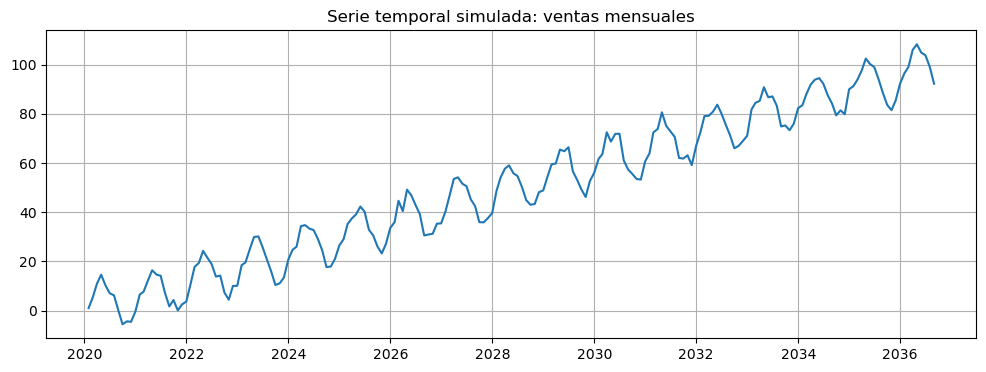

In [3]:
# Generar serie temporal simulada (200 puntos mensuales)
np.random.seed(42)
n = 200
t = np.arange(n)
tendencia = 0.5 * t
estacionalidad = 10 * np.sin(2 * np.pi * t / 12)   # ciclo cada 12 meses
ruido = np.random.normal(0, 2, n)
y = tendencia + estacionalidad + ruido

# Índice de fechas para mejor manejo
fechas = pd.date_range(start='2020-01-01', periods=n, freq='ME')
serie = pd.Series(y, index=fechas, name='ventas')

# Graficar
plt.figure(figsize=(12,4))
plt.plot(serie)
plt.title('Serie temporal simulada: ventas mensuales')
plt.grid(True)
plt.show()

In [4]:
# ## 🔬 4. Verificar estacionariedad (test de Dickey-Fuller Aumentado)

# %%
# H0: no estacionaria. Si p-valor < 0.05 -> estacionaria (rechazamos H0)
resultado = adfuller(serie)
print(f'Estadístico ADF: {resultado[0]:.4f}')
print(f'p-valor: {resultado[1]:.4f}')
if resultado[1] < 0.05:
    print("✔ La serie es estacionaria (podemos usar d=0)")
else:
    print("✘ La serie NO es estacionaria. Necesitamos diferenciar.")

# Observación: el p-valor será alto debido a la tendencia.

Estadístico ADF: 0.0271
p-valor: 0.9607
✘ La serie NO es estacionaria. Necesitamos diferenciar.


p-valor después de diferenciar: 0.0000
✔ Ahora la serie es estacionaria -> d=1


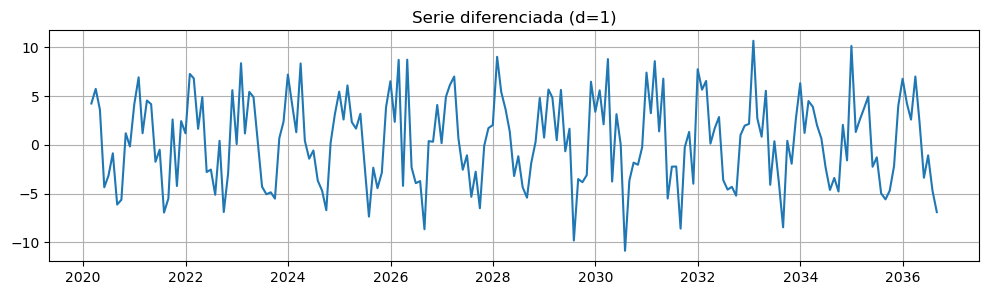

In [5]:
# ## 🔁 5. Diferenciación para eliminar tendencia (determinar d)

# %%
serie_diff = serie.diff().dropna()   # diferenciación de orden 1
resultado_diff = adfuller(serie_diff)
print(f'p-valor después de diferenciar: {resultado_diff[1]:.4f}')
if resultado_diff[1] < 0.05:
    print("✔ Ahora la serie es estacionaria -> d=1")
else:
    print("⚠️ Prueba con d=2")

# Graficar la serie diferenciada
plt.figure(figsize=(12,3))
plt.plot(serie_diff)
plt.title('Serie diferenciada (d=1)')
plt.grid(True)
plt.show()

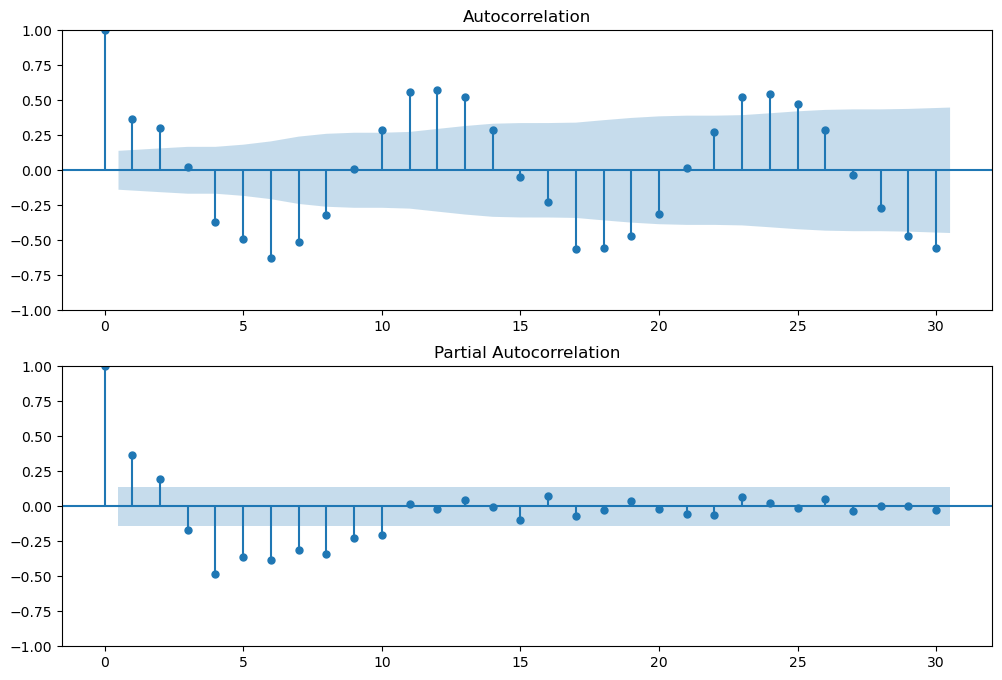

In [6]:
# ## 📈 6. Identificar p y q usando ACF y PACF

# %%
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(serie_diff, lags=30, ax=ax1)
plot_pacf(serie_diff, lags=30, ax=ax2)
plt.show()
